## Urban Infrastructure Failure Risk (ITNPBD6):  Practice Notebook
### 3539856


### Section 0: Library Imports and Configuration


In [142]:
# I start by importing data manipulation libraries
import pandas as pd
import numpy as np

# Importing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Importing maching learning libraries and required classes for assignment
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Now I import Keras via tensorflow which is a deeplearning library
from tensorflow import keras

# Suppress unnecessary warnings to keep notebook output clean
import warnings
warnings.filterwarnings("ignore")

# To ensure the result reproducibility, i use RANDOM_STATE in sklearn and keras
RANDOM_STATE = 42


### Section 1: Data Loading and EDA

In [143]:
# I start by loading the data from csv into dataframe 'df'
df = pd.read_csv("urbandata.csv")
print("Shape (rows, cols):", df.shape)
print("Columns:", df.columns.tolist())

#Check the entries of the dataset
df.head()




Shape (rows, cols): (456, 12)
Columns: ['inspector_id', 'material_flexibility', 'structural_mass_ratio', 'recent_precipitation', 'infrastructure_age', 'surface_debris', 'vibration_exposure', 'asset_density', 'inspection_season', 'inspection_window', 'moisture_stress', 'failure']


,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress,failure
0,5,31.762605,12.891996,4.711064,71.480592,9.429642,5.177088,2.9944,summer,afternoon,0.06,1
1,7,30.770158,11.835563,3.315888,60.300892,8.655641,4.927622,2.6808,spring,morning,0.01,0
2,6,31.591296,11.738267,2.425562,56.367965,9.017137,4.910945,2.5294,autumn,night,0.02,0
3,5,30.834649,11.622881,2.164486,53.135138,8.864650,4.949554,2.4810,autumn,afternoon,0.02,1
4,2,33.315981,12.616065,4.557082,77.482269,9.549344,5.047689,3.0460,summer,morning,0.07,1


In [144]:
# Now I check the data types of variables
df.dtypes

inspector_id               int64
material_flexibility     float64
structural_mass_ratio    float64
recent_precipitation     float64
infrastructure_age       float64
surface_debris           float64
vibration_exposure       float64
asset_density            float64
inspection_season         object
inspection_window         object
moisture_stress          float64
failure                    int64
dtype: object

In [145]:
# Counting missing values in each column
missing = df.isnull().sum()
# Now show columns with missing values only
missing = missing[missing>0].sort_values(ascending=False)
# Now lets print the columns with missing values only
print(missing)

infrastructure_age       4
moisture_stress          3
recent_precipitation     2
structural_mass_ratio    1
vibration_exposure       1
dtype: int64


In [146]:
# Now I check the target variable count and percentage
target_counts = df["failure"].value_counts().sort_index()
target_pct = df["failure"].value_counts(normalize=True).mul(100).round(2)
# Now I print the target variable count and percentage
print(target_counts)
print(target_pct)



failure
0    288
1    168
Name: count, dtype: int64
failure
0    63.16
1    36.84
Name: proportion, dtype: float64


inspector_id is treated as as identifier; candidate to drop before modeling.


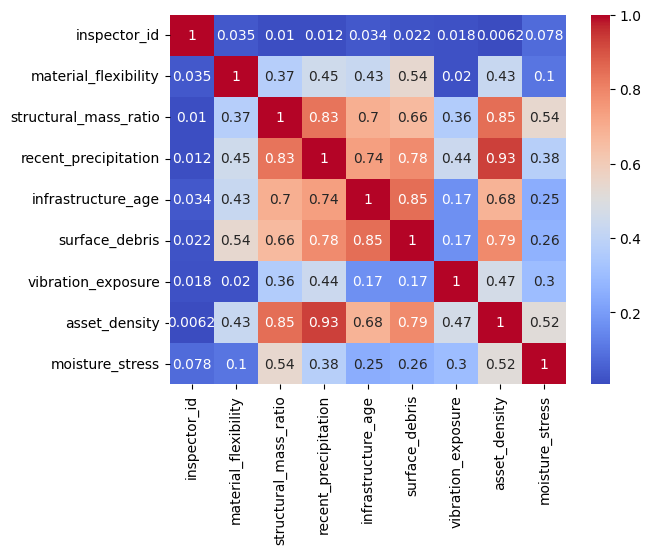

In [147]:
""" 
Now I will check the redundant columns and the ones having high correlation among themselves
I will start by flagging the identifier column
"""

# inspector_id is an ID, not a physical predictor.
print("inspector_id is treated as as identifier; candidate to drop before modeling.")

# Build numeric-only DataFrame and exclude target variable column
num_df = df.select_dtypes(include=["number"]).drop(columns=["failure"], errors="ignore")

# Now i calculate the absolute correlation between the columns
corr_matrix = num_df.corr().abs()
# Now i plot the correlation matrix using seaborn heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()


In [148]:
# Keep upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
upper

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,moisture_stress
inspector_id,NaN,0.034561,0.010414,0.011658,0.033680,0.021902,0.018135,0.006196,0.078406
material_flexibility,NaN,NaN,0.373450,0.450342,0.427320,0.540810,0.019700,0.427772,0.103187
structural_mass_ratio,NaN,NaN,NaN,0.833709,0.695421,0.661239,0.359906,0.845429,0.544956
recent_precipitation,NaN,NaN,NaN,NaN,0.738631,0.783012,0.439691,0.930145,0.375599
infrastructure_age,NaN,NaN,NaN,NaN,NaN,0.845629,0.167299,0.683343,0.246981
surface_debris,NaN,NaN,NaN,NaN,NaN,NaN,0.168003,0.789815,0.264388
vibration_exposure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.466034,0.298871
asset_density,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.515323
moisture_stress,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [149]:
# Flatten matrix to sorted pairs.
high_corr_pairs = upper.stack().sort_values(ascending=False)

# Filter very high correlations.
high_corr_pairs = high_corr_pairs[high_corr_pairs >= 0.85]

# Now i print the high correlation pairs result.
print("High-correlation pairs (>= 0.85):")
print(high_corr_pairs if not high_corr_pairs.empty else "None")





High-correlation pairs (>= 0.85):
recent_precipitation  asset_density    0.930145
dtype: float64


### Section 2: Train, Validate & Test Split

In [150]:
"""
I will start by creating the training, validation and testing datasets of Failure using statify
hyperparameter so that the each split keeps roughly the same propotion of each class 
as given in main dataset.
"""
# I will start by using target for stratified split
y = df['failure']

# First split: train+val (80%) and test (20%).
train_val, test_df = train_test_split(df, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# Second split: from train+val, create train (80%) and val (20%).
train_df, val_df = train_test_split(train_val, test_size=0.2, stratify=train_val["failure"], random_state=RANDOM_STATE)


In [151]:
"""
Now I will show how many rows are in each split as a result of above tain-test 
splitting excercise. We show class counts and percentages both.
"""
# Print split sizes.
print("Train size:", len(train_df), "| Val size:", len(val_df), "| Test size:", len(test_df))

# Train class distribution.
train_counts = train_df["failure"].value_counts().sort_index()
train_pct = train_df["failure"].value_counts(normalize=True).sort_index().mul(100).round(2)
print("\nTrain counts:\n", train_counts)
print("Train %:\n", train_pct)

# Validation class distribution.
val_counts = val_df["failure"].value_counts().sort_index()
val_pct = val_df["failure"].value_counts(normalize=True).sort_index().mul(100).round(2)
print("\nVal counts:\n", val_counts)
print("Val %:\n", val_pct)

# Test class distribution.
test_counts = test_df["failure"].value_counts().sort_index()
test_pct = test_df["failure"].value_counts(normalize=True).sort_index().mul(100).round(2)
print("\nTest counts:\n", test_counts)
print("Test %:\n", test_pct)



Train size: 291 | Val size: 73 | Test size: 92

Train counts:
 failure
0    184
1    107
Name: count, dtype: int64
Train %:
 failure
0    63.23
1    36.77
Name: proportion, dtype: float64

Val counts:
 failure
0    46
1    27
Name: count, dtype: int64
Val %:
 failure
0    63.01
1    36.99
Name: proportion, dtype: float64

Test counts:
 failure
0    58
1    34
Name: count, dtype: int64
Test %:
 failure
0    63.04
1    36.96
Name: proportion, dtype: float64


### Section 3: Finalizing Variable Tables and Preprocessing Decisions

In [152]:
"""
I have excluded inspector_id as it was identifier.
Moreover, After above analysis, I have decided to drop asset_density
as it is hightly correlated with recent_precipitation.
I will encode the categorical variables using one-hot encoding.
"""

target_col = "failure"
feature_cols = [
    "material_flexibility", "structural_mass_ratio", "recent_precipitation",
    "infrastructure_age", "surface_debris", "vibration_exposure",
    "inspection_season", "inspection_window", "moisture_stress"
]

cat_cols = ["inspection_season", "inspection_window"]
num_cols = [
    "material_flexibility", "structural_mass_ratio", "recent_precipitation",
    "infrastructure_age", "surface_debris", "vibration_exposure",
    "moisture_stress"
]

print("Target:", target_col)
print("Features:", feature_cols)
print("Categorical:", cat_cols)
print("Numeric:", num_cols)
print("Dropped: inspector_id, asset_density")
print("Reason: asset_density is highly correlated with recent_precipitation, so I kept the more direct variable (recent_precipitation).")

Target: failure
Features: ['material_flexibility', 'structural_mass_ratio', 'recent_precipitation', 'infrastructure_age', 'surface_debris', 'vibration_exposure', 'inspection_season', 'inspection_window', 'moisture_stress']
Categorical: ['inspection_season', 'inspection_window']
Numeric: ['material_flexibility', 'structural_mass_ratio', 'recent_precipitation', 'infrastructure_age', 'surface_debris', 'vibration_exposure', 'moisture_stress']
Dropped: inspector_id, asset_density
Reason: asset_density is highly correlated with recent_precipitation, so I kept the more direct variable (recent_precipitation).


### Section 4: Data Cleaning & Missing Values

In [153]:
"""
Now i will check for the missing values.
Whereever I find missing values, specificially in moisture_stress, 
I will impute them with the median value of the column.
"""
print("Missing moisture_stress (before):")
print("Train:", train_df["moisture_stress"].isnull().sum())
print("Val:", val_df["moisture_stress"].isnull().sum())
print("Test:", test_df["moisture_stress"].isnull().sum())



Missing moisture_stress (before):
Train: 2
Val: 0
Test: 1


In [154]:
# Now I will compute the median from training set for moisture_stress and plug into the rest of the missing values for this.
train_moisture_median = train_df["moisture_stress"].median()
print("Train median:", train_moisture_median)

train_df_clean = train_df.copy()
val_df_clean = val_df.copy()
test_df_clean = test_df.copy()

train_df_clean["moisture_stress"] = train_df_clean["moisture_stress"].fillna(train_moisture_median)
val_df_clean["moisture_stress"] = val_df_clean["moisture_stress"].fillna(train_moisture_median)
test_df_clean["moisture_stress"] = test_df_clean["moisture_stress"].fillna(train_moisture_median)

#Now I am verifying after inserting the median
print("Missing moisture_stress (after):")
print("Train:", train_df_clean["moisture_stress"].isnull().sum())
print("Val:", val_df_clean["moisture_stress"].isnull().sum())
print("Test:", test_df_clean["moisture_stress"].isnull().sum())


Train median: 0.02
Missing moisture_stress (after):
Train: 0
Val: 0
Test: 0


In [155]:
"""
Section 4 handles missing value identification.
The histogram for typo detection is shown in Section 5 (after the cleaning step).
"""

'\nSection 4 handles missing value identification.\nThe histogram for typo detection is shown in Section 5 (after the cleaning step).\n'

### Section 5: Building Feature Metrics & Final Cleaning Check

In [156]:
"""
Now i will convert the cleaned train,val and test sets into model-ready x and y.
I will fix category typos before one-hot encoding. (for example: `sumer` -> `summer`, `morni7ng` -> `morning`).
I will apply one-hot encoding to the categorical columns.
Then i will use StandardScaler to scale the numeric columns.
"""
# Create raw X and y from cleaned splits.
X_train_raw = train_df_clean[feature_cols].copy()
X_val_raw = val_df_clean[feature_cols].copy()
X_test_raw = test_df_clean[feature_cols].copy()

y_train = train_df_clean[target_col].copy()
y_val = val_df_clean[target_col].copy()
y_test = test_df_clean[target_col].copy()

# Standardize known category typos before one-hot encoding.
X_train_raw["inspection_season"] = X_train_raw["inspection_season"].replace({"sumer": "summer"})
X_val_raw["inspection_season"] = X_val_raw["inspection_season"].replace({"sumer": "summer"})
X_test_raw["inspection_season"] = X_test_raw["inspection_season"].replace({"sumer": "summer"})

X_train_raw["inspection_window"] = X_train_raw["inspection_window"].replace({"morni7ng": "morning"})
X_val_raw["inspection_window"] = X_val_raw["inspection_window"].replace({"morni7ng": "morning"})
X_test_raw["inspection_window"] = X_test_raw["inspection_window"].replace({"morni7ng": "morning"})

# Fill all numeric missing values using train medians (leakage-safe).
train_num_medians = X_train_raw[num_cols].median()
X_train_raw[num_cols] = X_train_raw[num_cols].fillna(train_num_medians)
X_val_raw[num_cols] = X_val_raw[num_cols].fillna(train_num_medians)
X_test_raw[num_cols] = X_test_raw[num_cols].fillna(train_num_medians)

# One-hot encode categorical columns.
X_train = pd.get_dummies(X_train_raw, columns=cat_cols, drop_first=True)
X_val = pd.get_dummies(X_val_raw, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test_raw, columns=cat_cols, drop_first=True)

print("Initial encoded shapes:")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("\nCheck typo columns:")
print("inspection_season_sumer in train columns:", "inspection_season_sumer" in X_train.columns)
print("inspection_window_morni7ng in train columns:", "inspection_window_morni7ng" in X_train.columns)
print("\nMissing values after numeric fill (train/val/test):",
      X_train[num_cols].isnull().sum().sum(),
      X_val[num_cols].isnull().sum().sum(),
      X_test[num_cols].isnull().sum().sum())

Initial encoded shapes:
Train: (291, 12) Val: (73, 12) Test: (92, 12)

Check typo columns:
inspection_season_sumer in train columns: False
inspection_window_morni7ng in train columns: False

Missing values after numeric fill (train/val/test): 0 0 0


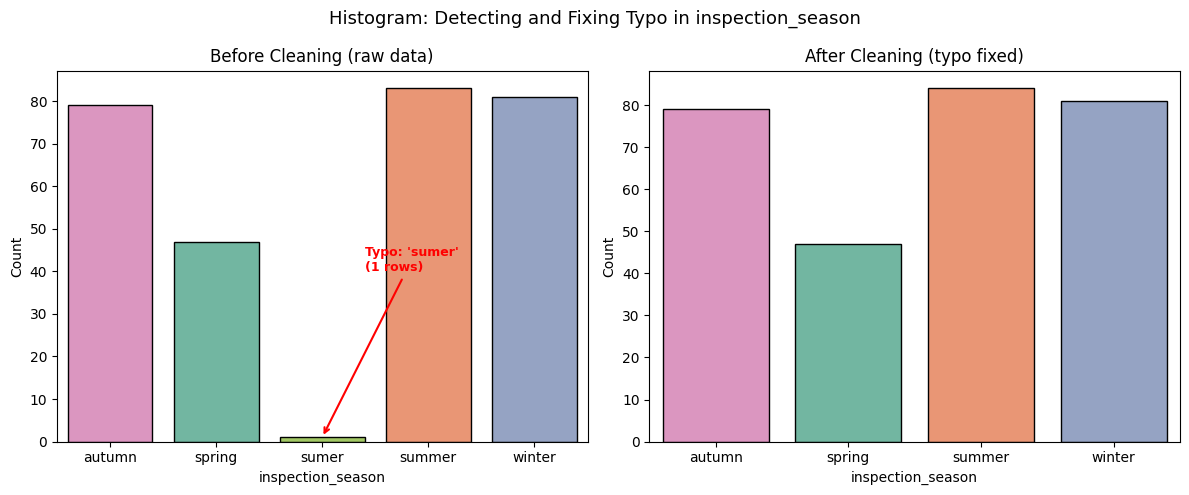

Error detected: 'sumer' appears as a separate category (should be 'summer').
Cleaning operation: replaced 'sumer' with 'summer' in all splits.


In [157]:
"""
I shall use Histogram to show typo detection and cleaning effect.
Before: train_df_clean has the raw 'sumer' typo.
After: X_train_raw has the corrected 'summer' value.
"""

from pathlib import Path
fig_dir = Path("figures")
fig_dir.mkdir(exist_ok=True)

# Before cleaning: raw season values from train_df_clean.
season_before = train_df_clean["inspection_season"]

# After cleaning: corrected values from X_train_raw (fixed in the cell above).
season_after = X_train_raw["inspection_season"]

# Side-by-side seaborn countplots.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=season_before, hue=season_before, order=sorted(season_before.unique()),
             palette="Set2", edgecolor="black", legend=False, ax=axes[0])
axes[0].set_title("Before Cleaning (raw data)")
axes[0].set_xlabel("inspection_season")
axes[0].set_ylabel("Count")

# Red annotation arrow pointing at the typo bar.
sumer_count = (season_before == "sumer").sum()
axes[0].annotate(f"Typo: 'sumer'\n({sumer_count} rows)",
                 xy=(2, sumer_count), xytext=(2.4, 40),
                 fontsize=9, color="red", fontweight="bold",
                 arrowprops=dict(arrowstyle="->", color="red", lw=1.5))

sns.countplot(x=season_after, hue=season_after, order=sorted(season_after.unique()),
             palette="Set2", edgecolor="black", legend=False, ax=axes[1])
axes[1].set_title("After Cleaning (typo fixed)")
axes[1].set_xlabel("inspection_season")
axes[1].set_ylabel("Count")

fig.suptitle("Histogram: Detecting and Fixing Typo in inspection_season", fontsize=13)
fig.tight_layout()
fig.savefig(fig_dir / "section5_histogram_typo_detection.png", dpi=300, bbox_inches="tight")
plt.show()

print("Error detected: 'sumer' appears as a separate category (should be 'summer').")
print("Cleaning operation: replaced 'sumer' with 'summer' in all splits.")

In [158]:
# Make val/test columns match train columns.
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Scale numeric columns only (fit on train only).
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Final aligned shapes:")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("\nModel-ready data prepared.")

Final aligned shapes:
Train: (291, 12) Val: (73, 12) Test: (92, 12)

Model-ready data prepared.


In [159]:
X_train.head()

,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,moisture_stress,inspection_season_spring,inspection_season_summer,inspection_season_winter,inspection_window_morning,inspection_window_night
127,-0.452301,-0.758832,-0.358561,0.343505,-0.734183,-1.614531,-0.098439,True,False,False,True,False
311,1.140357,1.617436,1.395007,2.365856,2.155840,-0.444075,1.129241,False,True,False,False,True
411,-0.212937,-0.473024,-0.232278,-0.794533,-0.512150,-0.211034,-0.507666,False,False,True,True,False
266,1.530288,3.297681,2.147388,1.982861,2.257280,-0.142560,2.356920,False,True,False,False,True
148,-0.495765,-0.851459,-1.406981,-1.551350,-0.739547,-1.177420,-0.507666,True,False,False,False,False


### Section:6 Logistic Regression

In [160]:
"""
Now i will train the logistic regression classifier.
I will use 2 values of C to check the hyperparameter comparion
"""

# Baseline logistic regression.
lr_base = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
lr_base.fit(X_train, y_train)

# Validation predictions and metrics.
y_val_pred_base = lr_base.predict(X_val)
lr_base_acc = accuracy_score(y_val, y_val_pred_base)
lr_base_f1 = f1_score(y_val, y_val_pred_base)

print("Baseline LR (C=1.0) - Val Accuracy:", round(lr_base_acc, 4))
print("Baseline LR (C=1.0) - Val F1:", round(lr_base_f1, 4))

Baseline LR (C=1.0) - Val Accuracy: 0.9315
Baseline LR (C=1.0) - Val F1: 0.9091


In [161]:
# Second simple LR setting.
lr_alt = LogisticRegression(C=0.3, max_iter=1000, random_state=RANDOM_STATE)
lr_alt.fit(X_train, y_train)

y_val_pred_alt = lr_alt.predict(X_val)
lr_alt_acc = accuracy_score(y_val, y_val_pred_alt)
lr_alt_f1 = f1_score(y_val, y_val_pred_alt)

print("Alt LR (C=0.3) - Val Accuracy:", round(lr_alt_acc, 4))
print("Alt LR (C=0.3) - Val F1:", round(lr_alt_f1, 4))

# Keep the better model by F1 (tie -> keep baseline).
if lr_alt_f1 > lr_base_f1:
    lr_model = lr_alt
    lr_best_C = 0.3
    lr_best_acc = lr_alt_acc
    lr_best_f1 = lr_alt_f1
else:
    lr_model = lr_base
    lr_best_C = 1.0
    lr_best_acc = lr_base_acc
    lr_best_f1 = lr_base_f1

print("\nChosen LR C:", lr_best_C)
print("Chosen LR Val Accuracy:", round(lr_best_acc, 4))
print("Chosen LR Val F1:", round(lr_best_f1, 4))

Alt LR (C=0.3) - Val Accuracy: 0.9178
Alt LR (C=0.3) - Val F1: 0.8889

Chosen LR C: 1.0
Chosen LR Val Accuracy: 0.9315
Chosen LR Val F1: 0.9091


### Section 7: Decision Tree

In [162]:
""" 
Now I will train the decision tree classifier.  
I will use 2 values of max_depth to check the hyperparameter comparion
"""

# Baseline decision tree.
dt_base = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt_base.fit(X_train, y_train)

# Validation predictions and metrics.
y_val_pred_dt_base = dt_base.predict(X_val)
dt_base_acc = accuracy_score(y_val, y_val_pred_dt_base)
dt_base_f1 = f1_score(y_val, y_val_pred_dt_base)

print("Baseline DT (max_depth=5) - Val Accuracy:", round(dt_base_acc, 4))
print("Baseline DT (max_depth=5) - Val F1:", round(dt_base_f1, 4))





Baseline DT (max_depth=5) - Val Accuracy: 0.8767
Baseline DT (max_depth=5) - Val F1: 0.8235


In [163]:
# Now I will try one more setting and choose the better model afterwards
# Alternative tree setting.
dt_alt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=3, random_state=RANDOM_STATE)
dt_alt.fit(X_train, y_train)

y_val_pred_dt_alt = dt_alt.predict(X_val)
dt_alt_acc = accuracy_score(y_val, y_val_pred_dt_alt)
dt_alt_f1 = f1_score(y_val, y_val_pred_dt_alt)

print("Alt DT (max_depth=8) - Val Accuracy:", round(dt_alt_acc, 4))
print("Alt DT (max_depth=8) - Val F1:", round(dt_alt_f1, 4))

# Keep better tree by F1.
if dt_alt_f1 > dt_base_f1:
    dt_model = dt_alt
    dt_best_name = "max_depth=8, min_samples_leaf=3"
    dt_best_acc = dt_alt_acc
    dt_best_f1 = dt_alt_f1
else:
    dt_model = dt_base
    dt_best_name = "max_depth=5, min_samples_leaf=5"
    dt_best_acc = dt_base_acc
    dt_best_f1 = dt_base_f1

print("\nChosen DT setting:", dt_best_name)
print("Chosen DT Val Accuracy:", round(dt_best_acc, 4))
print("Chosen DT Val F1:", round(dt_best_f1, 4))

Alt DT (max_depth=8) - Val Accuracy: 0.8767
Alt DT (max_depth=8) - Val F1: 0.8235

Chosen DT setting: max_depth=5, min_samples_leaf=5
Chosen DT Val Accuracy: 0.8767
Chosen DT Val F1: 0.8235


### Section 8: Neural Netowrk with Keras

In [164]:
""" 
Now I will train the neural network classifier.
I will use 2 values of max_depth to check the hyperparameter comparion
"""

# Convert DataFrames to float arrays for Keras.
X_train_nn = X_train.astype("float32").values
X_val_nn = X_val.astype("float32").values
X_test_nn = X_test.astype("float32").values

y_train_nn = y_train.values
y_val_nn = y_val.values
y_test_nn = y_test.values

# Baseline neural network.
nn_base = keras.Sequential([
    keras.layers.Input(shape=(X_train_nn.shape[1],)),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

nn_base.compile(optimizer="adam", loss="binary_crossentropy")
nn_base.fit(X_train_nn, y_train_nn, epochs=30, batch_size=16, verbose=0)

# Validation predictions and metrics.
y_val_prob_base = nn_base.predict(X_val_nn, verbose=0).ravel()
y_val_pred_nn_base = (y_val_prob_base >= 0.5).astype(int)

nn_base_acc = accuracy_score(y_val_nn, y_val_pred_nn_base)
nn_base_f1 = f1_score(y_val_nn, y_val_pred_nn_base)

print("Baseline NN (16 units) - Val Accuracy:", round(nn_base_acc, 4))
print("Baseline NN (16 units) - Val F1:", round(nn_base_f1, 4))# Baseline neural network.




Baseline NN (16 units) - Val Accuracy: 0.8904
Baseline NN (16 units) - Val F1: 0.8519


In [165]:
# Now I will try one more configuration to check the improvement

nn_alt = keras.Sequential([
    keras.layers.Input(shape=(X_train_nn.shape[1],)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

nn_alt.compile(optimizer="adam", loss="binary_crossentropy")
nn_alt.fit(X_train_nn, y_train_nn, epochs=30, batch_size=16, verbose=0)

y_val_prob_alt = nn_alt.predict(X_val_nn, verbose=0).ravel()
y_val_pred_nn_alt = (y_val_prob_alt >= 0.5).astype(int)

nn_alt_acc = accuracy_score(y_val_nn, y_val_pred_nn_alt)
nn_alt_f1 = f1_score(y_val_nn, y_val_pred_nn_alt)

print("Alt NN (32 units) - Val Accuracy:", round(nn_alt_acc, 4))
print("Alt NN (32 units) - Val F1:", round(nn_alt_f1, 4))

# Keep better model by F1.
if nn_alt_f1 > nn_base_f1:
    nn_model = nn_alt
    nn_best_name = "Dense(32)"
    nn_best_acc = nn_alt_acc
    nn_best_f1 = nn_alt_f1
else:
    nn_model = nn_base
    nn_best_name = "Dense(16)"
    nn_best_acc = nn_base_acc
    nn_best_f1 = nn_base_f1

print("\nChosen NN setting:", nn_best_name)
print("Chosen NN Val Accuracy:", round(nn_best_acc, 4))
print("Chosen NN Val F1:", round(nn_best_f1, 4))

Alt NN (32 units) - Val Accuracy: 0.9178
Alt NN (32 units) - Val F1: 0.8889

Chosen NN setting: Dense(32)
Chosen NN Val Accuracy: 0.9178
Chosen NN Val F1: 0.8889


### Section 9: Model Output Comparison & Final Choice

In [166]:
"""
Now I will make comparion of all 3 models with selected hyperparameters to decide which one to choose.

"""
model_comparison = pd.DataFrame({
    "model": ["Logistic Regression", "Decision Tree", "Neural Network (Keras)"],
    "validation_accuracy": [lr_best_acc, dt_best_acc, nn_best_acc],
    "validation_f1": [lr_best_f1, dt_best_f1, nn_best_f1],
    "best_setting": [f"C={lr_best_C}", dt_best_name, nn_best_name]
})

model_comparison = model_comparison.sort_values(by="validation_f1", ascending=False).reset_index(drop=True)
display(model_comparison)

print(" Conclusion: Based on the above comparion, we choose Logistic Regresion as the Final Choice Model.")


,model,validation_accuracy,validation_f1,best_setting
0,Logistic Regression,0.931507,0.909091,C=1.0
1,Neural Network (Keras),0.917808,0.888889,Dense(32)
2,Decision Tree,0.876712,0.823529,"max_depth=5, min_samples_leaf=5"


 Conclusion: Based on the above comparion, we choose Logistic Regresion as the Final Choice Model.


### Section 10: Final Test Evaluation of Logistic Regression & Confusion Metrics

Final model: Logistic Regression
Test Accuracy: 0.9783
Test F1: 0.9697
Confusion matrix:
 [[58  0]
 [ 2 32]]


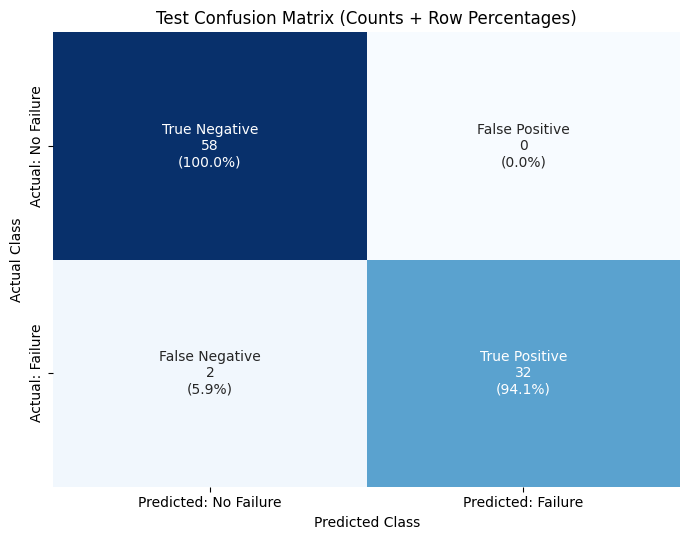

Saved figure: figures\section10_test_confusion_matrix.png
Failure recall: 94.1%
False negative rate (missed failures): 5.9%
False positive rate (false alarms): 0.0%


In [167]:
"""
Now I shall evaluate the Logistic Regression on the unexposed testing dataset and report Confusion Metrics
"""
# Choose Logistic Regression as final model.
final_model_name = "Logistic Regression"
final_model = lr_model
# Test predictions.
y_test_pred = final_model.predict(X_test)
# Final test metrics.
final_test_acc = accuracy_score(y_test, y_test_pred)
final_test_f1 = f1_score(y_test, y_test_pred)
cm_test = confusion_matrix(y_test, y_test_pred)
print("Final model:", final_model_name)
print("Test Accuracy:", round(final_test_acc, 4))
print("Test F1:", round(final_test_f1, 4))
print("Confusion matrix:\n", cm_test)


"""
Now I shall visualize test confusion metrics clearly and report key outputs
"""
from pathlib import Path
fig_dir = Path("figures")
fig_dir.mkdir(exist_ok=True)

# Cell counts from test confusion matrix.
true_negative, false_positive, false_negative, true_positive = cm_test.ravel()

# Convert to row-wise percentages so each actual class sums to 100%.
cm_pct = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)

# Build labels with full names, counts, and row percentages.
labels = np.array([
    [f"True Negative\n{true_negative}\n({cm_pct[0,0]:.1%})", f"False Positive\n{false_positive}\n({cm_pct[0,1]:.1%})"],
    [f"False Negative\n{false_negative}\n({cm_pct[1,0]:.1%})", f"True Positive\n{true_positive}\n({cm_pct[1,1]:.1%})"]
])

# Plot heatmap for clear interpretation.
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm_test, annot=labels, fmt="", cmap="Blues", cbar=False,
            xticklabels=["Predicted: No Failure", "Predicted: Failure"],
            yticklabels=["Actual: No Failure", "Actual: Failure"])
plt.title("Test Confusion Matrix (Counts + Row Percentages)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

confusion_figure_path = fig_dir / "section10_test_confusion_matrix.png"
plt.tight_layout()
plt.savefig(confusion_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", confusion_figure_path)

# Report core rates.
failure_recall = true_positive / (true_positive + false_negative)
false_negative_rate = false_negative / (true_positive + false_negative)
false_positive_rate = false_positive / (true_negative + false_positive)

print(f"Failure recall: {failure_recall:.1%}")
print(f"False negative rate (missed failures): {false_negative_rate:.1%}")
print(f"False positive rate (false alarms): {false_positive_rate:.1%}")

### Section 11: Additional Insight

In [168]:
"""
Lets identify the top 3 postive and negtive feature variables 
and their coeffient values that have the highest impact on the Failure Prediction.

"""

'\nLets identify the top 3 postive and negtive feature variables \nand their coeffient values that have the highest impact on the Failure Prediction.\n\n'

In [169]:
lr_coef_table = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": lr_model.coef_[0]
})

# Top 3 features with highest positive coefficients.
top_positive_coefficients = lr_coef_table.sort_values("coefficient", ascending=False).head(3)

# Top 3 features with lowest (most negative) coefficients.
top_negative_coefficients = lr_coef_table.sort_values("coefficient", ascending=True).head(3)

print("Top 3 positive coefficients:")
display(top_positive_coefficients[["feature", "coefficient"]])

print("Top 3 negative coefficients:")
display(top_negative_coefficients[["feature", "coefficient"]])

print("'inspection_season_summer' is the strongest feature, and higher values are linked to higher failure risk. ")


Top 3 positive coefficients:


,feature,coefficient
8,inspection_season_summer,2.012142
4,surface_debris,1.704811
2,recent_precipitation,0.783642


Top 3 negative coefficients:


,feature,coefficient
9,inspection_season_winter,-1.594628
7,inspection_season_spring,-0.960945
11,inspection_window_night,-0.193513


'inspection_season_summer' is the strongest feature, and higher values are linked to higher failure risk. 


------ END -------
